In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 设置 pandas 显示优化
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)
pd.set_option('display.max_colwidth',35)

# 设置显示中文
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 读取数据
df = pd.read_csv("7.Mall_Customers.csv")

# 初步观察数据情况
print(df.columns.tolist())
print(f"数据形状：{df.shape}")
print(f"\n前五行数据：\n{df.head()}")
print(f"\n数据类型与缺失值情况：")
print(df.info())
print(df.describe())

['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
数据形状：(200, 5)

前五行数据：
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

数据类型与缺失值情况：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null  

有 200 个数据，5 个特征。其中第一个 CustomerID 没有实际意义，需要去除。数据没有缺失值。年龄、年收入、消费分数相差很大，需要进行标准化处理。

性别要不要加入聚类特征？

- 利：性别可能会带来消费行为差异，理论上可以提供额外信息；
- 弊：
    - ① Gender 是分类特征（男 / 女），K‑Means 依靠欧氏距离，直接塞字符串不行，必须做独热编码；
    - ② 这个数据集业务经典做法：**很多教程选择不把性别放进聚类特征**。原因：年龄、年收入、消费得分是连续的行为核心指标；性别属于人口属性标签，可以聚类完成之后，**事后用来做画像统计，而不是参与距离计算**。

In [4]:
""" 查看性别分布 """
df.value_counts("Gender")

Gender
Female    112
Male       88
Name: count, dtype: int64

女性(56%)多于男性(44%)，但是相差不大。

In [6]:
""" 标准化 """
from sklearn.preprocessing import StandardScaler

feature_cols = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
X_raw = df[feature_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

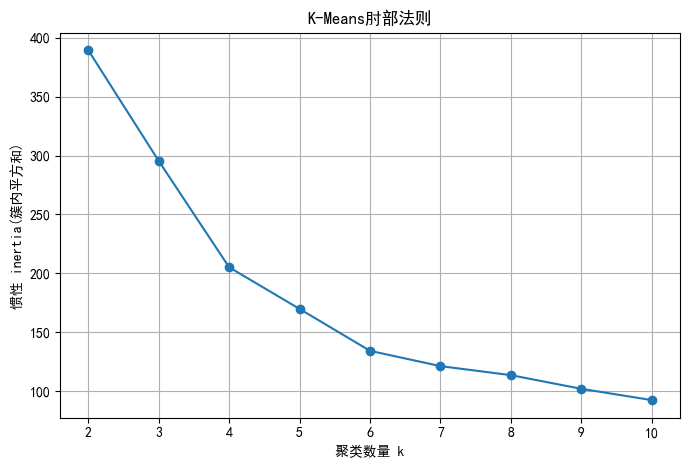

In [ ]:
""" 肘部法则，遍历 k, 计算 inertia 惯性 """
from sklearn.cluster import KMeans

inertia_list = []
k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    kmeans.fit(X_scaled)
    inertia_list.append(kmeans.inertia_)

# 绘制肘部图
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_list, marker="o")
plt.xlabel("聚类数量 k")
plt.ylabel("惯性 inertia(簇内平方和)")
plt.title("K-Means肘部法则")
plt.grid(1)
plt.show()

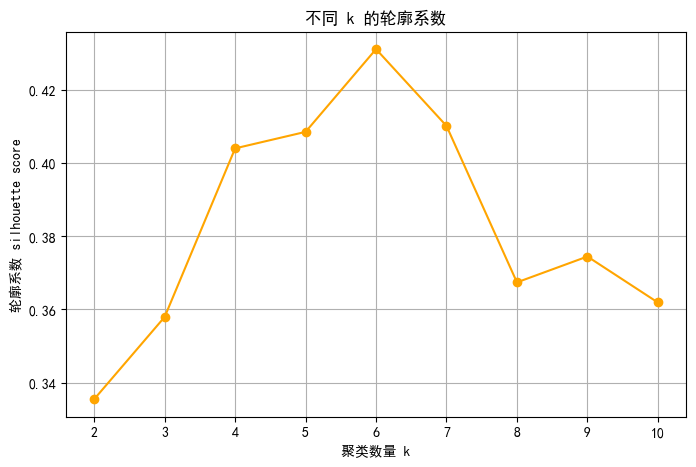

k = 2, 轮廓系数 = 0.3355
k = 3, 轮廓系数 = 0.3579
k = 4, 轮廓系数 = 0.4040
k = 5, 轮廓系数 = 0.4085
k = 6, 轮廓系数 = 0.4311
k = 7, 轮廓系数 = 0.4101
k = 8, 轮廓系数 = 0.3674
k = 9, 轮廓系数 = 0.3744
k = 10, 轮廓系数 = 0.3619


In [9]:
""" 计算每个 k 对应的轮廓系数 """
from sklearn.metrics import silhouette_score

sil_score_list = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = kmeans.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    sil_score_list.append(sil)

plt.figure(figsize=(8, 5))
plt.plot(k_range, sil_score_list, marker="o", color="orange")
plt.xlabel("聚类数量 k")
plt.ylabel("轮廓系数 silhouette score")
plt.title("不同 k 的轮廓系数")
plt.grid(1)
plt.show()

for k, score in zip(k_range, sil_score_list):
    print(f"k = {k}, 轮廓系数 = {score:.4f}")

k=6 轮廓系数指标最优，但是这个数据集业界经典业务分群是 **k=5**。这里体现无监督学习的关键点：**指标最优 ≠ 业务可解释最优**。

- k=6：数学指标最好，但有可能其中某一类人群样本量很小，业务含义模糊；
- k=5：轮廓系数 0.4085 略低于 6，但是 5 个客户群体每一类都有清晰商业画像，商场运营可以直接落地做营销。

In [11]:
""" 训练 k=5 最终 K-Means 模型，给原始 df 打上簇标签 """
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init="auto")
cluster_labels = kmeans_final.fit_predict(X_scaled)

df["cluster"] = cluster_labels # 把聚类标签追加回原始 DataFrame, 方便后续画像分析
print("每个簇样本数量:")
print(df["cluster"].value_counts().sort_index())

# 获取聚类中心点（标准化后的）
centers_scaled = kmeans_final.cluster_centers_

# 把中心点 反标准化，还原回真实业务数值（年龄、年收入、消费分数）
centers_origin = scaler.inverse_transform(centers_scaled)
centers_df = pd.DataFrame(centers_origin, columns=feature_cols)
print("\n各簇中心真实业务数值:")
print(centers_df.round(2))

每个簇样本数量:
cluster
0    58
1    40
2    26
3    45
4    31
Name: count, dtype: int64

各簇中心真实业务数值:
     Age  Annual Income (k$)  Spending Score (1-100)
0  55.28               47.62                   41.71
1  32.88               86.10                   81.53
2  25.77               26.12                   74.85
3  26.73               54.31                   40.91
4  44.39               89.77                   18.48


从结果看出：**消费行为不完全由收入年龄决定，消费意愿是独立维度**，这正是聚类挖掘出来的信息。

In [17]:
""" 遍历每个簇，查看【年龄-消费得分】统计 """
for c_id in sorted(df["cluster"].unique()):
    sub = df[df["cluster"] == c_id]
    print(f"\n======== 簇 {c_id} 样本量：{len(sub)} ========")
    print(f"年龄均值: {sub['Age'].mean():.2f}, min:{sub['Age'].min()}, max:{sub['Age'].max()}")
    print(f"消费得分均值: {sub['Spending Score (1-100)'].mean():.2f}, min:{sub['Spending Score (1-100)'].min()}, max:{sub['Spending Score (1-100)'].max()}")
    print(f"年收入均值: {sub['Annual Income (k$)'].mean():.2f}")


======== 簇 0 样本量：58 ========
年龄均值: 55.28, min:40, max:70
消费得分均值: 41.71, min:3, max:60
年收入均值: 47.62

======== 簇 1 样本量：40 ========
年龄均值: 32.88, min:27, max:40
消费得分均值: 81.53, min:58, max:97
年收入均值: 86.10

======== 簇 2 样本量：26 ========
年龄均值: 25.77, min:18, max:35
消费得分均值: 74.85, min:39, max:99
年收入均值: 26.12

======== 簇 3 样本量：45 ========
年龄均值: 26.73, min:18, max:40
消费得分均值: 40.91, min:5, max:60
年收入均值: 54.31

======== 簇 4 样本量：31 ========
年龄均值: 44.39, min:32, max:59
消费得分均值: 18.48, min:1, max:39
年收入均值: 89.77


In [19]:
""" 统计每个簇的男女比例 """
print("每个簇性别分布")
gender_cluster = pd.crosstab(df["cluster"], df["Gender"], normalize="index")
gender_cluster.round(3)

每个簇性别分布


Gender,Female,Male
cluster,,
0,0.569,0.431
1,0.550,0.450
2,0.577,0.423
3,0.600,0.400
4,0.484,0.516


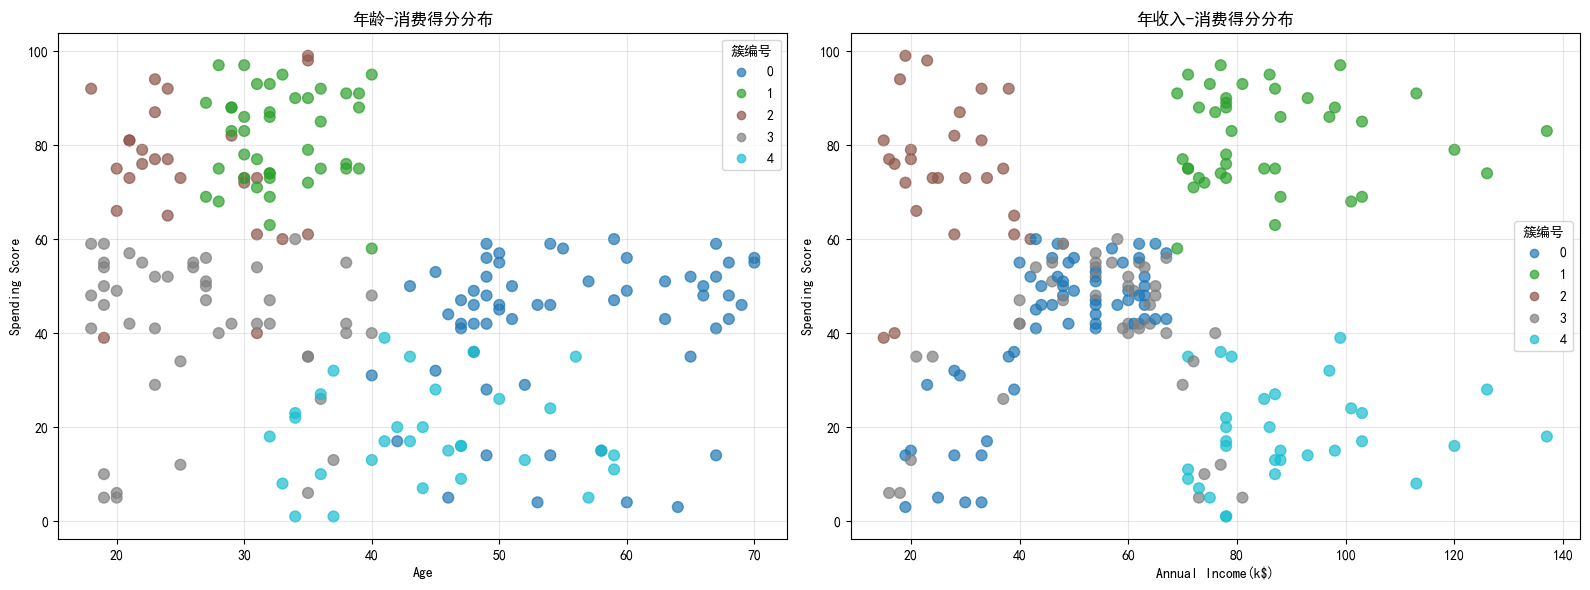

In [ ]:
""" 绘制二维散点图，区分人群 """
plt.figure(figsize=(16, 6))

# 图1：年龄-消费得分
plt.subplot(1, 2, 1)
scatter1 = plt.scatter(
    df["Age"],                      # x
    df["Spending Score (1-100)"],   # y
    c=df["cluster"],                # 按聚类簇编号给点上色
    cmap="tab10",                   # 配色方案，tab10 自带 10 种
    s=60,                           # 散点大小
    alpha=0.7                       # 透明度
)
plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.title("年龄-消费得分分布")
plt.legend(*scatter1.legend_elements(), title="簇编号")
plt.grid(alpha=0.3)

# 图2：年收入-消费得分
plt.subplot(1, 2, 2)
scatter2 = plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["cluster"],
    cmap="tab10",
    s=60,
    alpha=0.7
)
plt.xlabel("Annual Income(k$)")
plt.ylabel("Spending Score")
plt.title("年收入-消费得分分布")
plt.legend(*scatter2.legend_elements(), title="簇编号")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

| 簇号  | 样本数 | 平均年龄  | 平均年收入 (k$) | 平均消费得分 | 性别构成（女:男）            | 人群画像总结                  |
| --- | --- | ----- | ---------- | ------ | --------------- | -------------------------------------------------------- |
| 0   | 58  | 55.28 | 47.62      | 41.71  | 56.9% : 43.1%| **中老年保守群体**，年龄集中 40‑70 岁，中等收入，消费克制，不会疯狂消费。|
| 1   | 40  | 32.88 | 86.10      | 81.53  | 55.0% : 45.0% | ✨**核心高价值客户**，中青年，高收入、高消费意愿，消费得分普遍 58‑97，是商场最重要客群。|
| 2   | 26  | 25.77 | 26.12      | 74.85  | 57.7% : 42.3% | **低收入高消费年轻人（月光族）**，年龄 18‑35，收入不高，但愿意花钱享乐，消费欲望很强。|
| 3   | 45  | 26.73 | 54.31      | 40.91  | 60.0% : 40.0% | **普通青年群体**，年轻、中等收入，消费理性克制，不会冲动大额消费。|
| 4   | 31  | 44.39 | 89.77      | 18.48  | 48.4% : 51.6% | **高收入节俭人群**，中年，收入全场最高，但消费得分极低，有钱但是不愿意在商场消费。|

## 业务营销思考

1. **簇 1（高价值核心客户）**

- 策略：VIP 会员、专属折扣、高端新品优先推送，维护留存，防止流失。

2. **簇 2（年轻月光低收入高消费）**

- 策略：主推潮流、平价爆款，分期活动，刺激消费；虽然收入不高，但消费意愿强。

3. **簇 0（中老年保守）**

- 策略：性价比高、实用型商品，促销折扣，避免过度推销。

4. **簇 3（普通青年理性消费）**

- 策略：推送刚需日用品，做常规满减活动。

5. **簇 4（高收入极度节俭）**

- 策略：挖掘潜在需求，推送高端刚需产品；普通折扣很难打动这部分人，需要精准匹配需求。

In [28]:
""" 跑一下 k=6 时的情况 """
kmeans6 = KMeans(n_clusters=6, random_state=42, n_init="auto")
df["cluster_6"] = kmeans6.fit_predict(X_scaled)
print("k=6 每个簇样本数量：")
print(df["cluster_6"].value_counts().sort_index())

k=6 每个簇样本数量：
cluster_6
0    45
1    39
2    25
3    40
4    30
5    21
Name: count, dtype: int64


In [29]:
# 获取k=6聚类中心，还原原始业务数值
centers6_scaled = kmeans6.cluster_centers_
centers6_origin = scaler.inverse_transform(centers6_scaled)
centers6_df = pd.DataFrame(centers6_origin, columns=feature_cols)
print("k=6 各簇中心:")
print(centers6_df.round(2))

k=6 各簇中心:
     Age  Annual Income (k$)  Spending Score (1-100)
0  56.33               54.27                   49.07
1  32.69               86.54                   82.13
2  25.56               26.48                   76.24
3  26.12               59.42                   44.45
4  44.00               90.13                   17.93
5  45.52               26.29                   19.38


多了一簇，看似是簇 2 和 3，但其实是簇 5，因为 2 和 3 的区分点**不是年龄，而是年收入**！2 的年收入显著低于 3，而消费又明显高于 3。簇 5 在 k=5 的时候是并合并在了 0 中，k=6 时把他们分出来了。

## 业务层面权衡

1. k=6 数学上轮廓系数更高；新增簇 5 在统计上是独立一簇。
2. 但是业务实操角度：商场做营销，维护 6 套营销策略，成本比 5 套更高。

k=6 轮廓系数指标最优，可以拆分出中年低收入低消费客群；但 k=5 分组更少，每一类画像简洁清晰，业务落地成本更低，综合选择 k=5 作为最终聚类方案。